In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from osnap import *
import xarray as xr
import os
import scipy.signal as sig
import yt
yt.set_log_level(50)
import json
from matplotlib.animation import FuncAnimation, FFMpegWriter

run_date = "14may19"
alpha = 1.25
stir_path = f"/mnt/research/SNAPhU/STIR/run_sukhbold/run_{run_date}_a{alpha}/"

## Temperature vs Time

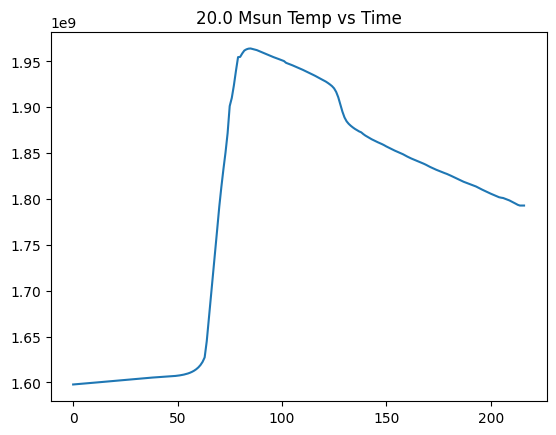

: 

In [ ]:
masses = ["20.0"]
peak_positions = {}
for mass in masses:
    file_path = f"/mnt/home/jdelker/_main/tools/flashbang/cache/run_14may19_a1.25/run_{mass}/run_{mass}_stir2_14may19_s{mass}_alpha1.25_tracers.nc"
    if not os.path.exists(file_path):
        continue
    data = xr.load_dataset(file_path)
    plt.plot(data["chk"], np.mean(data["temp"][:], axis=1))
    plt.title(f"{mass} Msun Temp vs Time")
    plt.show()

## Move tracer files from cache

In [ ]:
base_folder = f"/mnt/home/jdelker/_main/tools/flashbang/cache/run_14may19_a1.25"
new_folder = f"/mnt/home/jdelker/_main/projects/osnap/data/tracers"
for mass in config.all_masses:
    orig_path = f"{base_folder}/run_{mass}/run_{mass}_stir2_14may19_s{mass}_alpha1.25_tracers.nc"
    if not os.path.exists(orig_path):
        print(f"{mass} tracers do not exist.")
        continue
    new_path = f"{new_folder}/run_{mass}_stir2_14may19_s{mass}_alpha1.25_tracers.nc"
    if os.path.exists(new_path):
        print(f"{mass} tracers already exist in new location.")
        continue
    !cp {orig_path} {new_path}
    print(f"Moved {mass} tracers successfully.")

Moved 9.0 tracers successfully.
Moved 9.25 tracers successfully.
Moved 9.5 tracers successfully.
Moved 9.75 tracers successfully.
Moved 10.0 tracers successfully.
Moved 10.25 tracers successfully.
Moved 10.5 tracers successfully.
Moved 10.75 tracers successfully.
Moved 11.0 tracers successfully.
Moved 11.25 tracers successfully.
11.5 tracers do not exist.
Moved 11.75 tracers successfully.
Moved 12.0 tracers successfully.
12.25 tracers do not exist.
12.5 tracers do not exist.
12.75 tracers do not exist.
13.0 tracers do not exist.
13.1 tracers do not exist.
13.2 tracers do not exist.
13.3 tracers do not exist.
13.4 tracers do not exist.
13.5 tracers do not exist.
13.6 tracers do not exist.
13.7 tracers do not exist.
13.8 tracers do not exist.
13.9 tracers do not exist.
14.0 tracers do not exist.
14.1 tracers do not exist.
14.2 tracers do not exist.
14.3 tracers do not exist.
14.4 tracers do not exist.
14.5 tracers do not exist.
14.6 tracers do not exist.
14.7 tracers do not exist.
14.8 t

: 

## Plot Ti44 yields vs Compactness

In [17]:
run_date = "14may19"
masses = config.all_masses
alpha = "1.25"
tracer_count = "1000"
isotope = "ti44"
external_yields = "external_yields.txt"
xi_mass = 1.75 # 1.75 or 2.5
plot_name = f"ti44_vs_compactness_{xi_mass}"

with open(f'{config.main_data_directory}/compMu2.json', 'r') as file:
    stir_xi_data = json.load(file)

yields = pd.DataFrame(columns=["set", f"xi{xi_mass}", isotope])

if external_yields:
    external_data = pd.read_csv(f'{config.main_data_directory}/{external_yields}', sep='\s+', usecols=["set", f"xi{xi_mass}", isotope])
    external_data = external_data[external_data[f"xi{xi_mass}"] > 0]
    yields = pd.concat([yields, external_data], ignore_index=True)
    
for mass in masses:

    # Load the stitched data to get the yields
    path = f"{config.stitched_output_directory}/stitched_stir2_{run_date}_s{mass}_alpha{alpha}_n{tracer_count}"
    if not os.path.exists(path): continue
    data = pd.read_csv(path, sep='\s+')

    # Load STIR data from last checkpoint to get the PNS mass
    base_path = f"/mnt/research/SNAPhU/STIR/run_sukhbold/run_{run_date}_a{alpha}/run_{mass}"
    model_name = f"stir2_{run_date}_s{mass}_alpha{alpha}"
    _, shock_radius = np.loadtxt(base_path + "/" + model_name + ".dat", unpack=True, usecols=(0, 11))
    last_checkpoint = base_path + "/output/" + sorted([f for f in os.listdir(base_path + "/output") if "chk" in f])[-1]
    stir_data = yt.load(last_checkpoint).all_data()

    # Excise the PNS from the ejecta
    total_specific_energy = load_data.calculate_total_specific_energy(stir_data) + stir_data['flash', 'gpot'].value
    enclosed_mass = np.cumsum(stir_data['flash', 'cell_volume'].value * stir_data['gas', 'density'].value) / config.M_sun
    pns_masscut_index = np.min(np.where(total_specific_energy >= 0))
    pns_mass = enclosed_mass[pns_masscut_index]
    data = data[data["enclosed_mass"] > pns_mass]
    data = data[data["enclosed_mass"] < 3]

    # Get the total yields
    ejecta_mass = np.sum(data[isotope] * data["density"] * data["cell_volume"]) / config.M_sun
    model_compactness = stir_xi_data[mass][f"xi{xi_mass}"]
    yields = pd.concat([yields, pd.DataFrame([["STIR", float(model_compactness), ejecta_mass]], columns=yields.columns)], ignore_index=True)

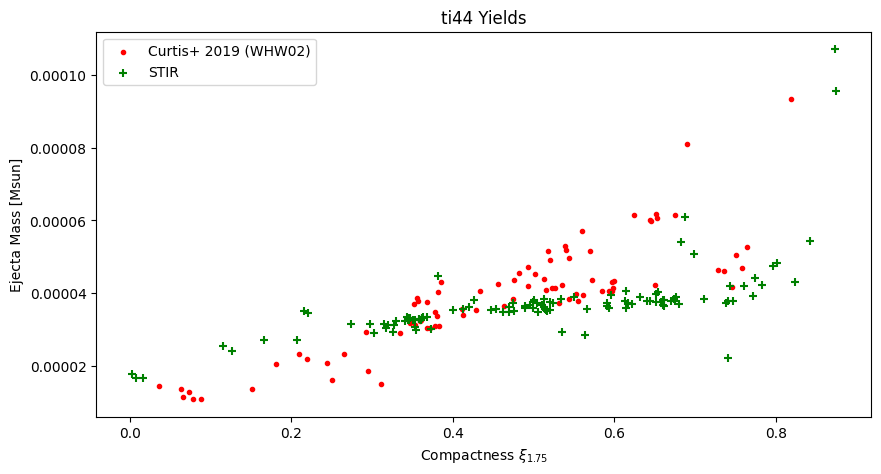

In [18]:
plt.figure(figsize=(10, 5))
sets = yields['set'].unique()
markers = ['.', '+', '+', '.']
colors = ['red', 'green', 'blue', 'black']

# Iterate over all rows of each set
for set_name in sets:
    set_index = np.where(sets == set_name)[0][0]
    current_set = yields[yields['set'] == set_name]
    xis = current_set[f"xi{xi_mass}"]
    set_yields = current_set[isotope]
    plt.scatter(xis, set_yields, label=set_name, marker=markers[set_index], color=colors[set_index])

plt.legend()
plt.title(f"{isotope} Yields")
plt.xlabel("Compactness $\\xi_{1.75}$")
plt.ylabel(f"Ejecta Mass [Msun]")
plt.savefig(f"{config.plot_directory}/{plot_name}.png")

## Ni56 vs Compactness

In [21]:
run_date = "14may19"
masses = config.all_masses
alpha = "1.25"
tracer_count = "1000"
isotope = "ni56"
external_yields = "external_yields.txt"
xi_mass = 1.75 # 1.75 or 2.5
plot_name = f"ni56_vs_compactness_{xi_mass}"

with open(f'{config.main_data_directory}/compMu2.json', 'r') as file:
    stir_xi_data = json.load(file)

yields = pd.DataFrame(columns=["set", f"xi{xi_mass}", isotope])
if external_yields:
    external_data = pd.read_csv(f'{config.main_data_directory}/{external_yields}', sep='\s+', usecols=["set", f"xi{xi_mass}", isotope])
    external_data = external_data[external_data[f"xi{xi_mass}"] > 0]
    yields = pd.concat([yields, external_data], ignore_index=True)
    
for mass in masses:

    # Load the stitched data to get the yields
    path = f"{config.stitched_output_directory}/stitched_stir2_{run_date}_s{mass}_alpha{alpha}_n{tracer_count}"
    if not os.path.exists(path): continue
    data = pd.read_csv(path, sep='\s+')

    # Load STIR data from last checkpoint to get the PNS mass
    base_path = f"/mnt/research/SNAPhU/STIR/run_sukhbold/run_{run_date}_a{alpha}/run_{mass}"
    model_name = f"stir2_{run_date}_s{mass}_alpha{alpha}"
    _, shock_radius = np.loadtxt(base_path + "/" + model_name + ".dat", unpack=True, usecols=(0, 11))
    last_checkpoint = base_path + "/output/" + sorted([f for f in os.listdir(base_path + "/output") if "chk" in f])[-1]
    stir_data = yt.load(last_checkpoint).all_data()

    # Excise the PNS from the ejecta
    total_specific_energy = load_data.calculate_total_specific_energy(stir_data) + stir_data['flash', 'gpot'].value
    enclosed_mass = np.cumsum(stir_data['flash', 'cell_volume'].value * stir_data['gas', 'density'].value) / config.M_sun
    pns_masscut_index = np.min(np.where(total_specific_energy >= 0))
    pns_mass = enclosed_mass[pns_masscut_index]
    data = data[data["enclosed_mass"] > pns_mass]

    # Get the total yields
    ejecta_mass = np.sum(data[isotope] * data["density"] * data["cell_volume"]) / config.M_sun
    model_compactness = stir_xi_data[mass][f"xi{xi_mass}"]
    yields = pd.concat([yields, pd.DataFrame([["STIR", float(model_compactness), ejecta_mass]], columns=yields.columns)], ignore_index=True)

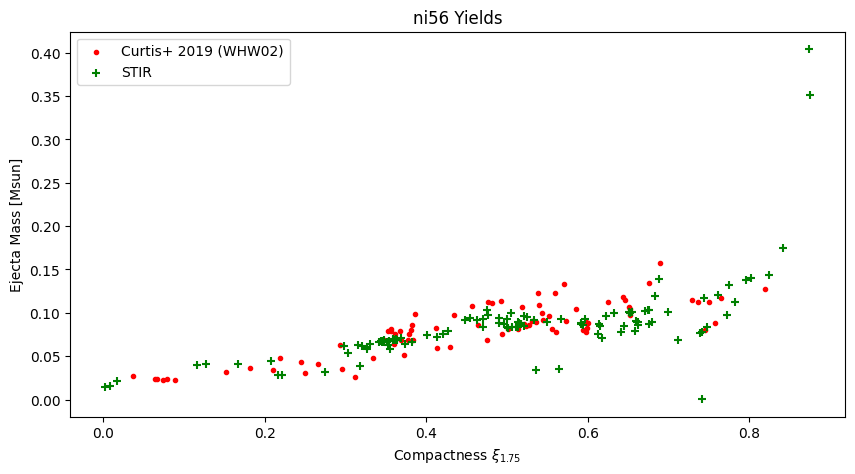

In [22]:
plt.figure(figsize=(10, 5))
sets = yields['set'].unique()
markers = ['.', '+', '+', '.']
colors = ['red', 'green', 'blue', 'black']

# Iterate over all rows of each set
for set_name in sets:
    set_index = np.where(sets == set_name)[0][0]
    current_set = yields[yields['set'] == set_name]
    xis = current_set[f"xi{xi_mass}"]
    set_yields = current_set[isotope]
    plt.scatter(xis, set_yields, label=set_name, marker=markers[set_index], color=colors[set_index])

plt.legend()
plt.title(f"{isotope} Yields")
plt.xlabel("Compactness $\\xi_{1.75}$")
plt.ylabel(f"Ejecta Mass [Msun]")
plt.savefig(f"{config.plot_directory}/{plot_name}.png")

## Calculating Compactness for WHW02 and WH07 models

In [ ]:
model_set = "WHW02"
set_name = f"Curtis+ 2019 ({model_set})"
calculated_values = {}

# Load the external data and make sure it has columns for the compactness parameters
external_data = pd.read_csv(f'{config.main_data_directory}/external_yields.txt', sep='\s+')
if "xi1.75" not in external_data.columns:
    external_data["xi1.75"] = np.ones(len(external_data)) * -1
if "xi2.5" not in external_data.columns:
    external_data["xi2.5"] = np.ones(len(external_data)) * -1

# Go through each file in the given directory and calculate compactness values
files = os.listdir(f"{config.main_data_directory}/{model_set}")
for file in files:
    mass, radius = np.loadtxt(f"{config.main_data_directory}/{model_set}/{file}", unpack=True, skiprows=2, usecols=(1,2))
    zams_mass = float(file[1:])
    radius1_75 = np.interp(1.75, mass / config.M_sun, radius)
    radius2_5 = np.interp(2.5, mass / config.M_sun, radius)
    calculated_values[zams_mass] = (1.75 / (radius1_75 / 1e8), 2.5 / (radius2_5 / 1e8))

# Update the compactness values in the external data file
for index, row in external_data.iterrows():
    if row["set"] == set_name:
        if row["zams_mass"] not in calculated_values:
            print(f"ZAMS mass {row['zams_mass']} compactness values missing.")
            continue
        external_data.loc[index, "xi1.75"] = calculated_values[row["zams_mass"]][0]
        external_data.loc[index, "xi2.5"] = calculated_values[row["zams_mass"]][1]

# Enforce a specific column order and save the updated file
external_data = external_data.loc[:, ["set", "zams_mass", "xi1.75", "xi2.5", "ni56", "ni56_error", "ni57", "ni57_error", "ni58", "ni58_error", "ti44", "ti44_error"]]
external_data.to_csv(f'{config.main_data_directory}/external_yields.txt', index=False, sep = ' ')

: 

In [ ]:
run_date = "14may19"
masses = config.all_masses
alpha = "1.25"
tracer_count = "1000"
isotope = "ni56"
external_yields = "external_yields.txt"
plot_name = "ni56_vs_compactness"
xi_mass = 2.5 # 1.75 or 2.5

with open(f'{config.main_data_directory}/compMu2.json', 'r') as file:
    stir_xi_data = json.load(file)

yields = pd.DataFrame(columns=["set", f"xi{xi_mass}", isotope])
for mass in masses:

    # Load the stitched data to get the yields
    path = f"{config.stitched_output_directory}/stitched_stir2_{run_date}_s{mass}_alpha{alpha}_n{tracer_count}"
    if not os.path.exists(path): continue
    data = pd.read_csv(path, sep='\s+')

    # Load STIR data from last checkpoint to get the PNS mass
    base_path = f"/mnt/research/SNAPhU/STIR/run_sukhbold/run_{run_date}_a{alpha}/run_{mass}"
    model_name = f"stir2_{run_date}_s{mass}_alpha{alpha}"
    _, shock_radius = np.loadtxt(base_path + "/" + model_name + ".dat", unpack=True, usecols=(0, 11))
    last_checkpoint = base_path + "/output/" + sorted([f for f in os.listdir(base_path + "/output") if "chk" in f])[-1]
    stir_data = yt.load(last_checkpoint).all_data()

    # Excise the PNS from the ejecta
    total_specific_energy = load_data.calculate_total_specific_energy(stir_data) + stir_data['flash', 'gpot'].value
    enclosed_mass = np.cumsum(stir_data['flash', 'cell_volume'].value * stir_data['gas', 'density'].value) / config.M_sun
    pns_masscut_index = np.min(np.where(total_specific_energy >= 0))
    pns_mass = enclosed_mass[pns_masscut_index]
    data = data[data["enclosed_mass"] > pns_mass]

    # Get the total yields
    ejecta_mass = np.sum(data[isotope] * data["density"] * data["cell_volume"]) / config.M_sun
    model_compactness = stir_xi_data[mass][f"xi{xi_mass}"]
    yields = pd.concat([yields, pd.DataFrame([["STIR", float(model_compactness), ejecta_mass]], columns=yields.columns)], ignore_index=True)

if external_yields:
    external_data = pd.read_csv(f'{config.main_data_directory}/{external_yields}', sep='\s+', usecols=["set", f"xi{xi_mass}", isotope])
    external_data = external_data[external_data[f"xi{xi_mass}"] > 0]
    yields = pd.concat([yields, external_data], ignore_index=True)

: 

<xarray.DataArray 'chk' ()> Size: 4B
array(217, dtype=int32)
Coordinates:
    chk      int32 4B 217


<xarray.DataArray 'ye  ' ()> Size: 8B
array(0.50931201)
Coordinates:
    chk      int32 4B 217

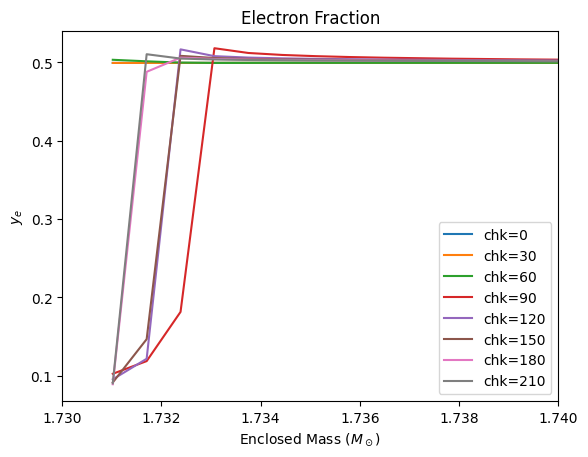

: 

In [ ]:
mass = 25.8
run_date = "14may19"
alpha = 1.25

data = xr.load_dataset(f"{config.main_data_directory}/tracers/run_{mass}_stir2_{run_date}_s{mass}_alpha{alpha}_tracers.nc")
chks = np.arange(0, data.coords["chk"][-1], 30)
print(data.coords["chk"][-1])
for chk in chks:
    plt.plot(data.coords["mass"], data["ye  "][chk], label = f"chk={chk}")
plt.xlim(1.73, 1.74)
plt.xlabel("Enclosed Mass ($M_\odot$)")
plt.ylabel("$y_e$")
plt.title("Electron Fraction")
plt.legend();
np.max(data["ye  "][-1])
# TODO: Sample dy_e/dm to determine mass element size for nucleosynthesis (use last checkpoint for calculating)
# TODO: Look at change in abundance of first peak of r-process (A~80) as a function of changing the electron fraction resolution


# Create an animated plot showing where and when Ti44 is produced

4.88256543476902e-05
1.3036468944941891e-05


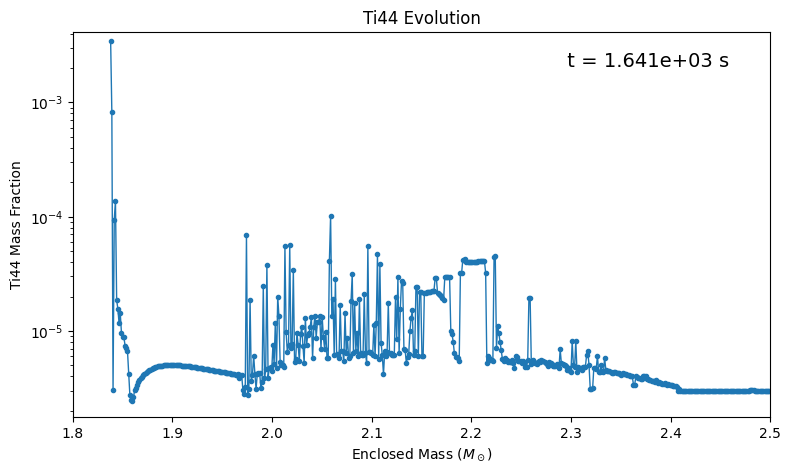

In [34]:
zams_mass = 20.0
tracers = 1000
skynet_output_path = f"{config.main_data_directory}/skynet_output/"
model_path = f"{skynet_output_path}/{run_date}_a{alpha}_run_{zams_mass}_n{tracers}"
isotope = "ti44"

full_path = f"{config.nucleo_results_directory}/{run_date}_m{zams_mass}_a{alpha}_n{tracers}"
dataset = xr.load_dataset(full_path)
isotope_index = np.argwhere(dataset.coords["isotope"].values == isotope)[0][0]

# Get the PNS mass and make a mask to excise the PNS from the ejecta
base_path = f"/mnt/research/SNAPhU/STIR/run_sukhbold/run_{run_date}_a{alpha}/run_{zams_mass}"
model_name = f"stir2_{run_date}_s{zams_mass}_alpha{alpha}"
_, shock_radius = np.loadtxt(base_path + "/" + model_name + ".dat", unpack=True, usecols=(0, 11))
last_checkpoint = base_path + "/output/" + sorted([f for f in os.listdir(base_path + "/output") if "chk" in f])[-1]
stir_data = yt.load(last_checkpoint).all_data()
total_specific_energy = load_data.calculate_total_specific_energy(stir_data) + stir_data['flash', 'gpot'].value
enclosed_mass = np.cumsum(stir_data['flash', 'cell_volume'].value * stir_data['gas', 'density'].value) / config.M_sun
pns_masscut_index = np.min(np.where(total_specific_energy >= 0))
pns_mass = enclosed_mass[pns_masscut_index]
mask = dataset.coords["mass"].values > pns_mass
cell_mass = (dataset.coords["mass"].values[1:] - dataset.coords["mass"].values[:-1])[0]
y_mass = dataset["Y"].values[mask, isotope_index, :]
num_frames = y_mass.shape[1]

path = f"{config.stitched_output_directory}/stitched_stir2_{run_date}_s{zams_mass}_alpha{alpha}_n{tracers}"
stitched_data = pd.read_csv(path, sep='\s+')
stitched_data = stitched_data[stitched_data["enclosed_mass"] > dataset.coords["mass"].values[-1]]
extra_mass = np.sum(stitched_data[isotope] * stitched_data["density"] * stitched_data["cell_volume"]) / config.M_sun
print(extra_mass)
total_mass = np.sum(cell_mass * y_mass[:, -1])# + extra_mass
print(total_mass)

fig, ax = plt.subplots(figsize=(9, 5))
line, = ax.plot(dataset.coords["mass"].values[mask], y_mass[:, 0], ".-", lw=1)
ax.set_xlabel("Enclosed Mass ($M_\\odot$)")
ax.set_ylabel("Ti44 Mass Fraction")
ax.set_title("Ti44 Evolution")
ax.set_xlim(1.8, 2.5)
ax.set_yscale("log")

positive = y_mass[y_mass > 0]
if positive.size > 0:
    ax.set_ylim(positive.min() * 0.8, positive.max() * 1.2)

text = ax.text(0.7, 0.95, "", transform=ax.transAxes, va="top", ha="left", fontsize = 14)

def update(frame_idx):
    line.set_ydata(y_mass[:, frame_idx])
    total_mass = np.sum(cell_mass * y_mass[:, frame_idx])# + extra_mass
    #print(total_mass)
    time_val = dataset.coords["time"].values[frame_idx] if "time" in dataset.coords else frame_idx
    text.set_text(f" t = {time_val:.3e} s")#\nM = {total_mass:.3e} $M_\\odot$")
    return line, text

ani = FuncAnimation(fig, update, frames=num_frames, interval=1, blit=True)

save_path = f"{config.plot_directory}/ti44_evolution_m{zams_mass}_a{alpha}_n{tracers}"
ani.save(f"{save_path}.mp4", writer=FFMpegWriter(fps=10, bitrate=1800))

plt.show()

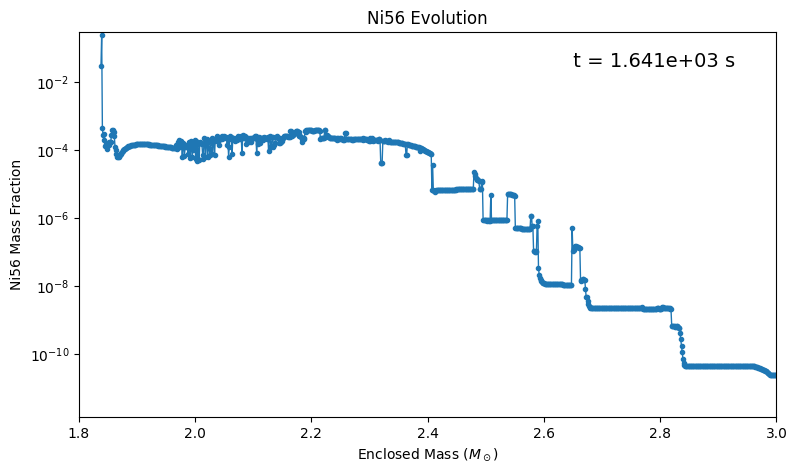

: 

In [ ]:
zams_mass = 20.0
tracers = 1000
skynet_output_path = f"{config.main_data_directory}/skynet_output/"
model_path = f"{skynet_output_path}/{run_date}_a{alpha}_run_{zams_mass}_n{tracers}"
isotope = "ni56"

full_path = f"{config.nucleo_results_directory}/{run_date}_m{zams_mass}_a{alpha}_n{tracers}"
dataset = xr.load_dataset(full_path)
isotope_index = np.argwhere(dataset.coords["isotope"].values == isotope)[0][0]

# Get the PNS mass and make a mask to excise the PNS from the ejecta
base_path = f"/mnt/research/SNAPhU/STIR/run_sukhbold/run_{run_date}_a{alpha}/run_{zams_mass}"
model_name = f"stir2_{run_date}_s{zams_mass}_alpha{alpha}"
_, shock_radius = np.loadtxt(base_path + "/" + model_name + ".dat", unpack=True, usecols=(0, 11))
last_checkpoint = base_path + "/output/" + sorted([f for f in os.listdir(base_path + "/output") if "chk" in f])[-1]
stir_data = yt.load(last_checkpoint).all_data()
total_specific_energy = load_data.calculate_total_specific_energy(stir_data) + stir_data['flash', 'gpot'].value
enclosed_mass = np.cumsum(stir_data['flash', 'cell_volume'].value * stir_data['gas', 'density'].value) / config.M_sun
pns_masscut_index = np.min(np.where(total_specific_energy >= 0))
pns_mass = enclosed_mass[pns_masscut_index]
mask = dataset.coords["mass"].values > pns_mass

mass_vals = dataset.coords["mass"].values[mask]
cell_mass = (dataset.coords["mass"].values[1:] - dataset.coords["mass"].values[:-1])
cell_mass = cell_mass[0]
y_mass = dataset["Y"].values[mask, isotope_index, :]
num_frames = y_mass.shape[1]

fig, ax = plt.subplots(figsize=(9, 5))
line, = ax.plot(mass_vals, y_mass[:, 0], ".-", lw=1)
ax.set_xlabel("Enclosed Mass ($M_\\odot$)")
ax.set_ylabel("Ni56 Mass Fraction")
ax.set_title("Ni56 Evolution")
ax.set_xlim(1.8, 3.0)
ax.set_yscale("log")

positive = y_mass[y_mass > 0]
if positive.size > 0:
    ax.set_ylim(positive.min() * 0.8, positive.max() * 1.2)

text = ax.text(0.7, 0.95, "", transform=ax.transAxes, va="top", ha="left", fontsize = 14)

def update(frame_idx):
    line.set_ydata(y_mass[:, frame_idx])
    total_mass = np.sum(cell_mass * y_mass[:, frame_idx])
    time_val = dataset.coords["time"].values[frame_idx] if "time" in dataset.coords else frame_idx
    text.set_text(f" t = {time_val:.3e} s")#\nM = {total_mass:.3e} $M_\\odot$")
    return line, text

ani = FuncAnimation(fig, update, frames=num_frames, interval=1, blit=True)

save_path = f"{config.plot_directory}/ni56_evolution_m{zams_mass}_a{alpha}_n{tracers}"
ani.save(f"{save_path}.mp4", writer=FFMpegWriter(fps=10, bitrate=1800))

plt.show()

: 